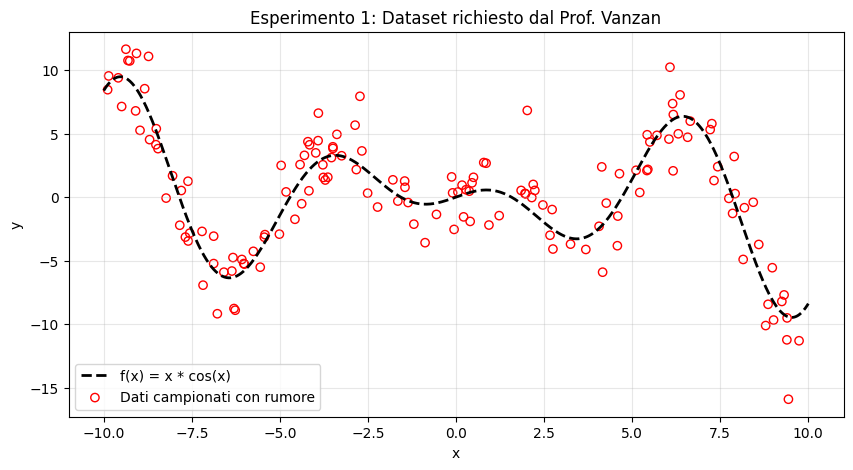

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ESPERIMENTO 1: Approssimazione di f(x) = x*cos(x)
# ==========================================

# 1. Definiamo la funzione vera
def f_vera(x):
    return x * np.cos(x)

# 2. Generiamo i dati di addestramento (Campionati casualmente, come richiesto)
np.random.seed(42) # Per avere sempre gli stessi numeri casuali mentre testiamo
N_punti = 150
x_train_new = np.random.uniform(-10, 10, N_punti) # Punti casuali tra -10 e 10
x_train_new = np.sort(x_train_new) # Li ordiniamo solo per comodità grafica

# 3. Aggiungiamo il rumore: y_i = f(x_i) + rumore
rumore = np.random.normal(0, 2.0, N_punti) # Rumore gaussiano
y_train_new = f_vera(x_train_new) + rumore

# 4. Creiamo la curva continua "perfetta" per il confronto visivo
x_true_new = np.linspace(-10, 10, 1000)
y_true_new = f_vera(x_true_new)

# 5. Visualizziamo il nuovo problema
plt.figure(figsize=(10, 5))
plt.plot(x_true_new, y_true_new, 'k--', linewidth=2, label='f(x) = x * cos(x)')
plt.scatter(x_train_new, y_train_new, facecolors='none', edgecolors='red', label='Dati campionati con rumore')
plt.title("Esperimento 1: Dataset richiesto dal Prof. Vanzan")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Inizio ROLS su f(x) = x*cos(x)...

Step 01: Aggiunto centro in x=-9.89 | GCV=440483.1112
Step 02: Aggiunto centro in x=9.74 | GCV=76055.4644
Step 03: Aggiunto centro in x=-6.59 | GCV=24711.6645
Step 04: Aggiunto centro in x=6.65 | GCV=9168.2195
Step 05: Aggiunto centro in x=-3.49 | GCV=4255.6458
Step 06: Aggiunto centro in x=3.68 | GCV=2729.1732
Step 07: Aggiunto centro in x=-9.59 | GCV=1974.7913
Step 08: Aggiunto centro in x=1.96 | GCV=1464.6739
Step 09: Aggiunto centro in x=5.50 | GCV=1132.2899
Step 10: Aggiunto centro in x=-0.88 | GCV=894.6126
Step 11: Aggiunto centro in x=-3.25 | GCV=743.4887
Step 12: Aggiunto centro in x=3.25 | GCV=632.5163
Step 13: Aggiunto centro in x=6.04 | GCV=567.0845
Step 14: Aggiunto centro in x=9.01 | GCV=497.9934
Step 15: Aggiunto centro in x=7.43 | GCV=469.9569
Step 16: Aggiunto centro in x=2.24 | GCV=448.6412
Step 17: Aggiunto centro in x=4.16 | GCV=436.4681
Step 18: Aggiunto centro in x=-0.56 | GCV=395.5228
Step 19: Aggiunto centro in x=1.23 | GCV=373.

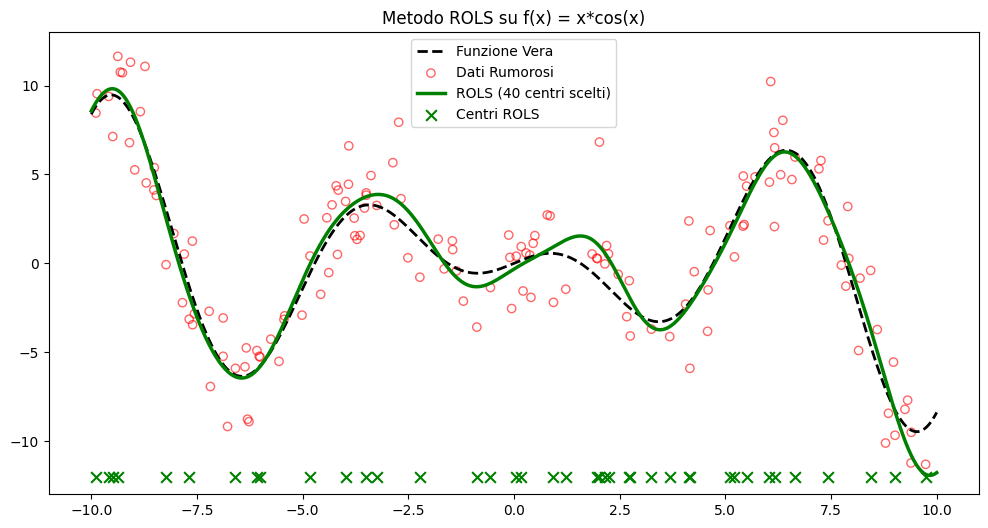

In [2]:
# ==========================================
# ESPERIMENTO 1: ROLS (Regularized Forward Selection)
# ==========================================

# Ridefiniamo la funzione base per sicurezza
def gaussiane_rbf(x, c, r):
    return np.exp(-((x - c)**2) / (r**2))

r_new = 1.5 # NUOVO RAGGIO PIÙ GRANDE per coprire il dominio [-10, 10]
lam_rols = 1e-2 # Parametro di regolarizzazione

max_centri = 40 # Ci basteranno meno di 40 centri
centri_rols = []
indici_rimanenti = list(range(len(x_train_new)))
storia_gcv = []
miglior_gcv = float('inf')
p = len(x_train_new)

print("Inizio ROLS su f(x) = x*cos(x)...\n")

for step in range(max_centri):
    miglior_candidato_idx = -1
    min_errore_step = float('inf')
    
    for idx in indici_rimanenti:
        candidato = x_train_new[idx]
        centri_temp = centri_rols + [candidato]
        
        H_temp = np.zeros((p, len(centri_temp)))
        for j, c in enumerate(centri_temp):
            H_temp[:, j] = gaussiane_rbf(x_train_new, c, r_new)
            
        I_temp = np.eye(len(centri_temp))
        inv_matrix_temp = np.linalg.inv(H_temp.T @ H_temp + lam_rols * I_temp)
        w_temp = inv_matrix_temp @ H_temp.T @ y_train_new
        y_pred_temp = H_temp @ w_temp
        
        sse_temp = np.sum((y_train_new - y_pred_temp)**2)
        if sse_temp < min_errore_step:
            min_errore_step = sse_temp
            miglior_candidato_idx = idx
            
    # Aggiornamento
    nuovo_centro = x_train_new[miglior_candidato_idx]
    centri_rols.append(nuovo_centro)
    indici_rimanenti.remove(miglior_candidato_idx)
    
    # Valutazione GCV
    H_uff = np.zeros((p, len(centri_rols)))
    for j, c in enumerate(centri_rols):
        H_uff[:, j] = gaussiane_rbf(x_train_new, c, r_new)
        
    I_uff = np.eye(len(centri_rols))
    inv_matrix_uff = np.linalg.inv(H_uff.T @ H_uff + lam_rols * I_uff)
    w_uff = inv_matrix_uff @ H_uff.T @ y_train_new
    S = np.sum((y_train_new - (H_uff @ w_uff))**2)
    P = H_uff @ inv_matrix_uff @ H_uff.T
    traccia_P = np.trace(P)
    
    gcv = (p * S) / (traccia_P**2)
    storia_gcv.append(gcv)
    print(f"Step {step+1:02d}: Aggiunto centro in x={nuovo_centro:.2f} | GCV={gcv:.4f}")
    
    if step > 2 and gcv > miglior_gcv * 1.02:
        print("\n[!] GCV in salita (Overfitting imminente). Mi fermo.")
        centri_rols.pop()
        break
    else:
        if gcv < miglior_gcv: miglior_gcv = gcv

# DISEGNO DEL GRAFICO ROLS
H_test_rols = np.zeros((len(x_true_new), len(centri_rols)))
for j, c in enumerate(centri_rols):
    H_test_rols[:, j] = gaussiane_rbf(x_true_new, c, r_new)

H_final = np.zeros((p, len(centri_rols)))
for j, c in enumerate(centri_rols):
    H_final[:, j] = gaussiane_rbf(x_train_new, c, r_new)
w_final = np.linalg.inv(H_final.T @ H_final + lam_rols * np.eye(len(centri_rols))) @ H_final.T @ y_train_new
y_pred_rols = H_test_rols @ w_final

plt.figure(figsize=(12, 6))
plt.plot(x_true_new, y_true_new, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train_new, y_train_new, facecolors='none', edgecolors='red', alpha=0.6, label='Dati Rumorosi')
plt.plot(x_true_new, y_pred_rols, 'g-', linewidth=2.5, label=f'ROLS ({len(centri_rols)} centri scelti)')
plt.scatter(centri_rols, np.full(len(centri_rols), -12), color='green', marker='x', s=60, label='Centri ROLS')
plt.title(f"Metodo ROLS su f(x) = x*cos(x)")
plt.legend()
plt.ylim([-13, 13])
plt.show()

Epoca 1000/5000 | Loss (MSE): 2.9275
Epoca 2000/5000 | Loss (MSE): 2.9373
Epoca 3000/5000 | Loss (MSE): 2.9090
Epoca 4000/5000 | Loss (MSE): 2.7458
Epoca 5000/5000 | Loss (MSE): 2.7438


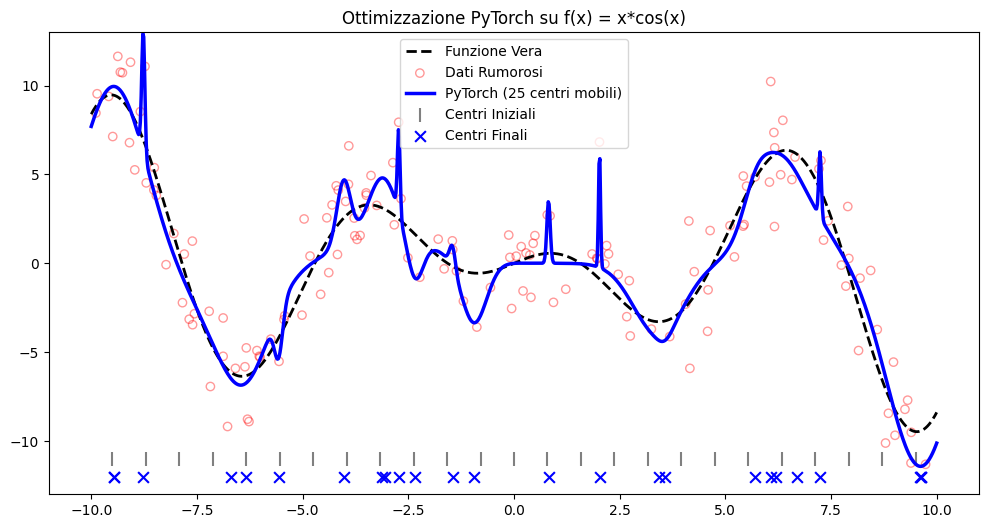

In [4]:
# ==========================================
# ESPERIMENTO 1: PyTorch su f(x) = x*cos(x)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

x_train_t = torch.tensor(x_train_new, dtype=torch.float32).view(-1, 1)
y_train_t = torch.tensor(y_train_new, dtype=torch.float32).view(-1, 1)
x_test_t = torch.tensor(x_true_new, dtype=torch.float32).view(-1, 1)

class RBFNetwork_New(nn.Module):
    def __init__(self, num_centers):
        super(RBFNetwork_New, self).__init__()
        # Inizializziamo i centri spalmati nel nuovo dominio [-9.5, 9.5]
        self.centers = nn.Parameter(torch.linspace(-9.5, 9.5, num_centers).unsqueeze(0))
        # Partiamo con un log_sigma di 0.5 (sigma circa 1.6)
        self.log_sigmas = nn.Parameter(torch.full((1, num_centers), 0.5))
        self.weights = nn.Parameter(torch.randn(num_centers, 1) * 0.1)
        
    def forward(self, x):
        distances_sq = (x - self.centers)**2 
        sigmas = torch.exp(self.log_sigmas)
        phi = torch.exp(-distances_sq / (sigmas**2))
        return phi @ self.weights

# Usiamo 25 centri per questo problema più largo
num_neuroni = 25
model = RBFNetwork_New(num_centers=num_neuroni)
centri_iniziali = model.centers.detach().numpy().flatten()

# Weight decay = Ridge Regression in PyTorch!
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1e-3)
criterion = nn.MSELoss()

epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoca {epoch+1:04d}/{epochs} | Loss (MSE): {loss.item():.4f}")

# Estrazione risultati
with torch.no_grad():
    y_pred_pytorch = model(x_test_t).numpy().flatten()
    centri_finali = model.centers.numpy().flatten()

plt.figure(figsize=(12, 6))
plt.plot(x_true_new, y_true_new, 'k--', linewidth=2, label='Funzione Vera')
plt.scatter(x_train_new, y_train_new, facecolors='none', edgecolors='red', alpha=0.4, label='Dati Rumorosi')
plt.plot(x_true_new, y_pred_pytorch, 'b-', linewidth=2.5, label=f'PyTorch ({num_neuroni} centri mobili)')
plt.scatter(centri_iniziali, np.full(num_neuroni, -11), color='gray', marker='|', s=100, label='Centri Iniziali')
plt.scatter(centri_finali, np.full(num_neuroni, -12), color='blue', marker='x', s=60, label='Centri Finali')
plt.title("Ottimizzazione PyTorch su f(x) = x*cos(x)")
plt.legend()
plt.ylim([-13, 13])
plt.show()

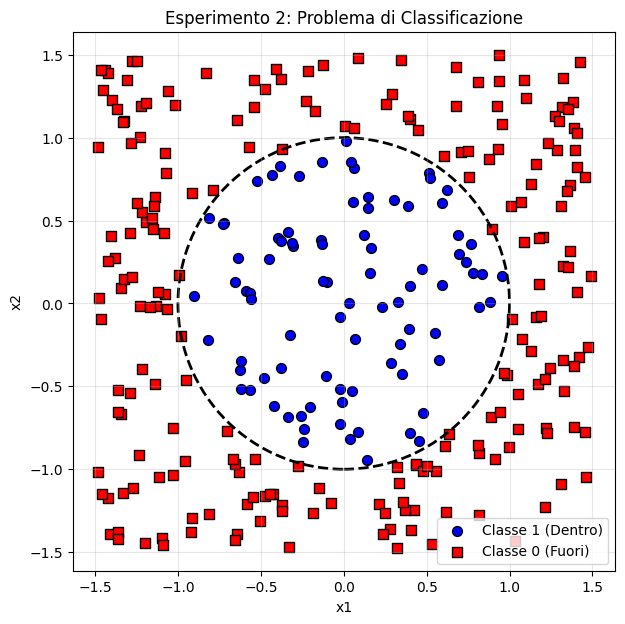

In [3]:
# ==========================================
# ESPERIMENTO 2: Classificazione (Dentro o Fuori dal Cerchio?)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Generiamo 300 punti casuali in 2D (coordinate x1 e x2 tra -1.5 e 1.5)
# X sarà una matrice con 300 righe e 2 colonne
N_punti_class = 300
X_class = np.random.uniform(-1.5, 1.5, (N_punti_class, 2)) 

# 2. Definiamo la regola segreta: il cerchio di raggio R = 1
# L'equazione del cerchio è x1^2 + x2^2 <= raggio^2
raggio = 1.0
distanza_dal_centro_al_quadrato = X_class[:, 0]**2 + X_class[:, 1]**2

# Se la distanza è <= 1, l'etichetta è 1 (Dentro). Altrimenti 0 (Fuori).
# astype(int) trasforma i True/False in 1/0
Y_class = (distanza_dal_centro_al_quadrato <= raggio**2).astype(int) 

# 3. Visualizziamo il dataset del professore
plt.figure(figsize=(7, 7))

# Disegniamo i punti Classe 1 (Dentro) e Classe 0 (Fuori)
plt.scatter(X_class[Y_class == 1, 0], X_class[Y_class == 1, 1], facecolors='blue', edgecolors='k', label='Classe 1 (Dentro)', s=50)
plt.scatter(X_class[Y_class == 0, 0], X_class[Y_class == 0, 1], facecolors='red', edgecolors='k', marker='s', label='Classe 0 (Fuori)', s=50)

# Disegniamo il cerchio tratteggiato per far capire il confine geometrico
cerchio_ideale = plt.Circle((0, 0), raggio, color='black', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(cerchio_ideale)

plt.title("Esperimento 2: Problema di Classificazione")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.axis('equal') # Mantiene le proporzioni corrette tra gli assi
plt.grid(True, alpha=0.3)
plt.show()